# Long Short Portfolio

## Portfolio Rules

Long Top 20 Stocks

Short Bottom 20 Stocks

Equal Weight Construction

## Objective

Evaluate whether the model can identify both winners and losers.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test = pd.read_csv(
    "v2_predictions.csv",
    index_col=[0,1],
    parse_dates=[0]
)

test.head()

mom21     mom63    mom126     vol21     vol63  \
Date                                                                        
2022-01-03 3MINDIA.NS   -0.000492  0.037566  0.060943  0.015019  0.014196   
           ABB.NS        0.061129  0.186427  0.229553  0.028616  0.024826   
           ACC.NS       -0.004796  0.006190  0.127931  0.016365  0.015481   
           AIAENG.NS     0.008258 -0.037923 -0.118066  0.013237  0.012564   
           APLAPOLLO.NS  0.025720  0.118160  0.155668  0.026467  0.024544   

                         ema_distance  ema_slope      rsi14  future_return  \
Date                                                                         
2022-01-03 3MINDIA.NS        0.020394  -0.004152  61.477420      -0.031571   
           ABB.NS            0.038912   0.025155  42.984065       0.041375   
           ACC.NS           -0.007693  -0.021376  41.161351       0.024519   
           AIAENG.NS        -0.003623  -0.010820  54.338304       0.033490   
           APLAPOLLO.NS     -0.000077   0.029442  28.654798      -0.027867   

                         market_mom21  market_vol21  rank_mom21  rank_mom63  \
Date                                                                          
2022-01-03 3MINDIA.NS        0.039417      0.012684    0.364458    0.629518   
           ABB.NS            0.039417      0.012684    0.686747    0.870482   
           ACC.NS            0.039417      0.012684    0.328313    0.524096   
           AIAENG.NS         0.039417      0.012684    0.424699    0.337349   
           APLAPOLLO.NS      0.039417      0.012684    0.518072    0.774096   

                         rank_mom126  rank_vol21  rank_vol63  rank_rsi14  \
Date                                                                       
2022-01-03 3MINDIA.NS       0.451807    0.174699    0.078313    0.795181   
           ABB.NS           0.689759    0.834337    0.596386    0.277108   
           ACC.NS           0.551205    0.246988    0.108434    0.216867   
           AIAENG.NS        0.147590    0.090361    0.039157    0.614458   
           APLAPOLLO.NS     0.596386    0.780120    0.581325    0.036145   

                         future_relative_return  prediction  pred_bucket  
Date                                                                      
2022-01-03 3MINDIA.NS                 -0.053508   -0.000927            5  
           ABB.NS                      0.019438    0.000209            5  
           ACC.NS                      0.002582   -0.000928            5  
           AIAENG.NS                   0.011554   -0.006534            1  
           APLAPOLLO.NS               -0.049804   -0.001740            4

In [2]:
rebalance_dates = (
    test.index
    .get_level_values(0)
    .unique()[::21]
)

In [3]:
ls_returns = []

dates = []

for date in rebalance_dates:

    group = test.loc[date]

    longs = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    shorts = (
        group
        .nsmallest(
            20,
            "prediction"
        )
    )

    long_return = (
        longs[
            "future_return"
        ]
        .mean()
    )

    short_return = (
        shorts[
            "future_return"
        ]
        .mean()
    )

    portfolio_return = (
        long_return
        -
        short_return
    )

    ls_returns.append(
        portfolio_return
    )

    dates.append(
        date
    )

In [4]:
ls_returns = pd.Series(
    ls_returns,
    index=dates
)

ls_equity = (
    1 +
    ls_returns
).cumprod()

In [5]:
def performance_stats(
    returns
):

    equity = (
        1 +
        returns
    ).cumprod()

    total_return = (
        equity.iloc[-1]
        - 1
    )

    years = (
        equity.index[-1]
        -
        equity.index[0]
    ).days / 365.25

    cagr = (
        equity.iloc[-1]
        **
        (1 / years)
        - 1
    )

    sharpe = (
        returns.mean()
        /
        returns.std()
        *
        np.sqrt(
            252 / 21
        )
    )

    drawdown = (
        equity
        /
        equity.cummax()
        - 1
    )

    max_dd = drawdown.min()

    return pd.Series({

        "Total Return":
            total_return,

        "CAGR":
            cagr,

        "Sharpe":
            sharpe,

        "Max DD":
            max_dd

    })

In [6]:
performance_stats(
    ls_returns
)

stats = performance_stats(
    ls_returns
)

print(stats)

Total Return    0.561857
CAGR            0.120802
Sharpe          0.943328
Max DD         -0.154765
dtype: float64


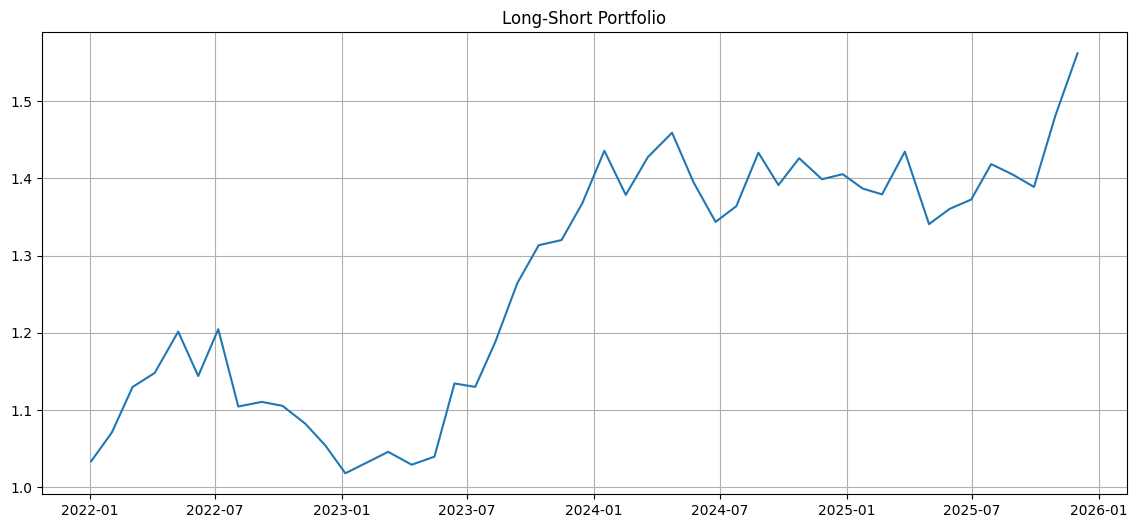

In [7]:
plt.figure(
    figsize=(14,6)
)

plt.plot(
    ls_equity
)

plt.title(
    "Long-Short Portfolio"
)

plt.grid(True)

plt.show()

In [8]:
win_rate = (
    ls_returns > 0
).mean()

print(
    f"Win Rate: {win_rate:.2%}"
)

Win Rate: 61.70%


In [9]:
long_returns = []

short_returns = []

for date in rebalance_dates:

    group = test.loc[date]

    longs = (
        group
        .nlargest(
            20,
            "prediction"
        )
    )

    shorts = (
        group
        .nsmallest(
            20,
            "prediction"
        )
    )

    long_returns.append(

        longs[
            "future_return"
        ].mean()

    )

    short_returns.append(

        shorts[
            "future_return"
        ].mean()

    )

print(
    "Average Long Return:",
    np.mean(long_returns)
)

print(
    "Average Short Return:",
    np.mean(short_returns)
)

Average Long Return: 0.022913523462677804
Average Short Return: 0.012693968048086948
